# Validate one RTSTRUCT ROI and reference mesh

This notebook only visualizes artifacts produced by `scripts/rtstruct_mesh.py build`. All DICOM parsing, rasterization, mesh extraction, and round-trip validation live in reusable Python modules.

In [1]:
from pathlib import Path
from functools import lru_cache
import json

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from ipywidgets import IntSlider, interact
from matplotlib.lines import Line2D
from scipy import ndimage as ndi
from skimage.measure import marching_cubes

from medgs4d.mesh_validation import (
    load_case,
    mask_boundary,
    window_hu,
)
from medgs4d.meshes import (
    load_mesh_npz,
    mesh_to_mask_roundtrip,
)
from medgs4d.rtstruct import load_geometry

## Configuration

In [2]:
# Change only this path.
SERIES_DIR = Path(
    "/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/prepared/"
    "patient117_20001024_annotated/rtstruct_mesh/tumor_4d"
)

STUDY_NAME = SERIES_DIR.parents[1].name

STACK_ROOT = next(
    parent
    for parent in SERIES_DIR.parents
    if (parent / "data").is_dir()
    and (parent / "results").is_dir()
)

RUN_ROOT = (
    STACK_ROOT
    / "results"
    / "medgs4d"
    / STUDY_NAME
)

RUN_CANDIDATES = sorted(
    path
    for path in RUN_ROOT.iterdir()
    if path.is_dir()
    and list(
        (
            path
            / "evaluation"
            / "mesh_transfer"
        ).glob("iter_*/predictions.npz")
    )
)

assert len(RUN_CANDIDATES) == 1, (
    "Expected exactly one evaluated MedGS4D run, found: "
    f"{RUN_CANDIDATES}"
)

RUN_DIR = RUN_CANDIDATES[0]

TRANSFER_CANDIDATES = sorted(
    (
        RUN_DIR
        / "evaluation"
        / "mesh_transfer"
    ).glob("iter_*/predictions.npz")
)

assert len(TRANSFER_CANDIDATES) == 1, (
    "Expected exactly one mesh-transfer result, found: "
    f"{TRANSFER_CANDIDATES}"
)

MESH_TRANSFER_DIR = TRANSFER_CANDIDATES[0].parent

GAUSSIAN_GEOMETRY_DIR = (
    RUN_DIR
    / "evaluation"
    / "gaussian_geometry"
    / MESH_TRANSFER_DIR.name
)

case = load_case(SERIES_DIR / "phase_00")

manifest = case["manifest"]
geometry = case["geometry"]
ct = case["ct_volume"]
mask = case["mask"]
roundtrip = case["roundtrip_mask"]
mesh = case["mesh"]
contours = case["contours"]
report = case["report"]

transfer_metrics = pd.read_csv(
    MESH_TRANSFER_DIR / "per_phase.csv"
)

mesh_transfer_summary = json.loads(
    (MESH_TRANSFER_DIR / "summary.json").read_text()
)

gaussian_geometry_summary = json.loads(
    (GAUSSIAN_GEOMETRY_DIR / "summary.json").read_text()
)

predictions = np.load(
    MESH_TRANSFER_DIR / "predictions.npz",
    allow_pickle=False,
)

prediction_phases = predictions["phases"].astype(int)
predicted_vertices_xyz = predictions["vertices_xyz_mm"]
predicted_displacements_xyz = predictions[
    "vertex_displacement_xyz_mm"
]
prediction_faces = predictions["faces"]

phase_to_prediction_index = {
    int(phase): index
    for index, phase in enumerate(prediction_phases)
}

gaussian_sample = np.load(
    GAUSSIAN_GEOMETRY_DIR
    / "canonical_gaussian_sample.npz",
    allow_pickle=False,
)

sample_inside = gaussian_sample[
    "inside_volume"
].astype(bool)

canonical_gaussian_index_zyx = gaussian_sample[
    "index_zyx"
][sample_inside]


@lru_cache(maxsize=10)
def load_phase_case(phase: int) -> dict:
    return load_case(
        SERIES_DIR / f"phase_{int(phase):02d}"
    )


@lru_cache(maxsize=10)
def predicted_mask_for_phase(phase: int) -> np.ndarray:
    phase = int(phase)
    phase_case = load_phase_case(phase)
    prediction_index = phase_to_prediction_index[phase]

    vertices_zyx = phase_case[
        "geometry"
    ].patient_xyz_to_index_zyx(
        predicted_vertices_xyz[prediction_index]
    )

    return mesh_to_mask_roundtrip(
        vertices_zyx,
        prediction_faces,
        phase_case["geometry"].shape_zyx,
    )


REFERENCE_COLOR = "limegreen"
PREDICTION_COLOR = "crimson"
GAUSSIAN_COLOR = "dodgerblue"

print(f"Study: {STUDY_NAME}")
print(f"Series: {SERIES_DIR}")
print(f"Run: {RUN_DIR}")
print(f"Transfer results: {MESH_TRANSFER_DIR}")
print(f"Evaluated phases: {prediction_phases.tolist()}")

Study: patient117_20001024_annotated
Series: /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/prepared/patient117_20001024_annotated/rtstruct_mesh/tumor_4d
Run: /home/jovyan/shared/mtm_medgs_stack/results/medgs4d/patient117_20001024_annotated/phase00_canon15000_denoised_holdout_iter7000
Transfer results: /home/jovyan/shared/mtm_medgs_stack/results/medgs4d/patient117_20001024_annotated/phase00_canon15000_denoised_holdout_iter7000/evaluation/mesh_transfer/iter_007000
Evaluated phases: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


## Numerical validation report

In [3]:
display(pd.DataFrame({"Value": report}).rename_axis("Metric"))
display(pd.read_csv(SERIES_DIR / "phase_00" / manifest["contour_report_file"]).head(20))


,Value
Metric,
contour_count,7
ct_series_instance_uid,1.3.6.1.4.1.14519.5.2.1.6834.5010.148529694733...
ct_series_path,/home/jovyan/shared/mtm_medgs_stack/data/tcia_...
finite_vertices,True
mask_volume_mm3,8097.316784
mask_voxels,2830
mesh_bounds_xyz_mm,"[[-59.485299999999995, -1.7700999999999851, -9..."
mesh_faces,4398
mesh_mask_relative_volume_error,0.009541


,ContourIndex,SliceIndex,ReferencedSOPInstanceUID,GeometricType,PointCount,MaxPlaneDistanceMm,MinRow,MaxRow,MinColumn,MaxColumn
0,5,86,1.3.6.1.4.1.14519.5.2.1.6834.5010.136106450049...,CLOSED_PLANAR,47,0.0006,254.010342,267.009830,213.991194,230.990477
1,4,87,1.3.6.1.4.1.14519.5.2.1.6834.5010.657024264762...,CLOSED_PLANAR,80,0.0006,241.010854,271.009625,207.991399,234.990375
2,3,88,1.3.6.1.4.1.14519.5.2.1.6834.5010.314034886296...,CLOSED_PLANAR,80,0.0006,243.010854,273.009625,204.991604,232.990477
3,2,89,1.3.6.1.4.1.14519.5.2.1.6834.5010.310558486315...,CLOSED_PLANAR,75,0.0006,243.010854,270.009728,206.991501,231.990477
4,0,90,1.3.6.1.4.1.14519.5.2.1.6834.5010.257084638965...,CLOSED_PLANAR,71,0.0006,243.010854,270.009728,208.991399,229.990580
5,6,91,1.3.6.1.4.1.14519.5.2.1.6834.5010.104025054558...,CLOSED_PLANAR,73,0.0005,245.010752,267.009830,210.991296,236.990272
6,1,92,1.3.6.1.4.1.14519.5.2.1.6834.5010.333941856009...,CLOSED_PLANAR,46,0.0005,243.010854,258.010240,219.990989,235.990272


## Phase-specific axial projections

Blue points are sampled canonical Gaussian centers.

Green contours show the phase-specific RTSTRUCT reference. Red contours show the tumor mesh predicted by transferring MedGS4D Gaussian motion.

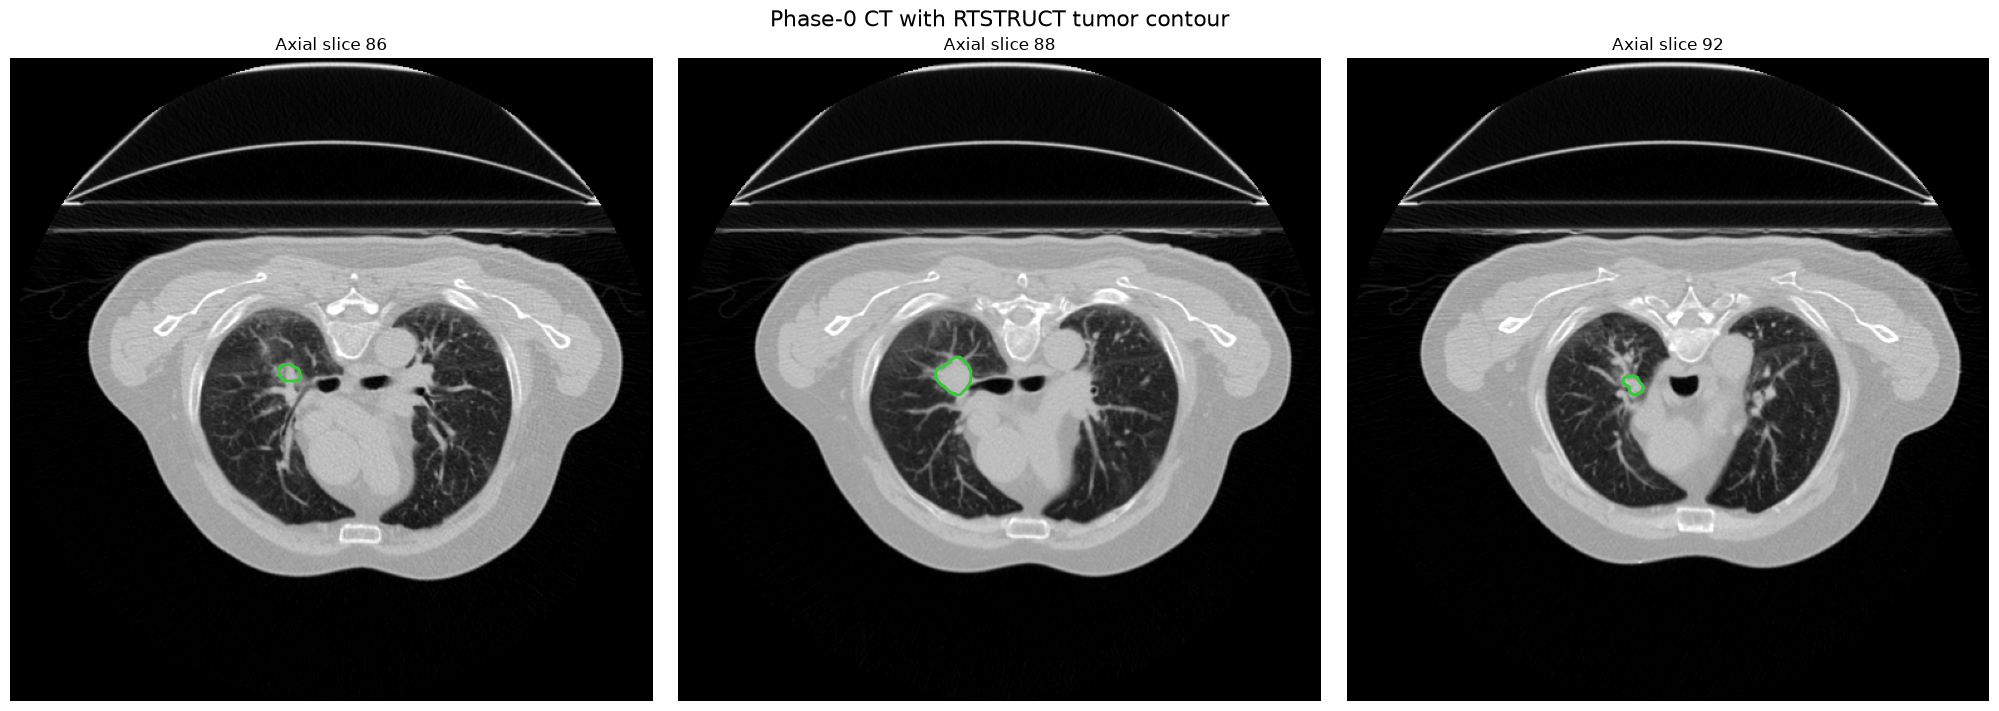

In [5]:
areas = mask.reshape(
    mask.shape[0],
    -1,
).sum(axis=1)

occupied_slices = np.flatnonzero(areas)

selected_slices = [
    int(occupied_slices[0]),
    int(np.argmax(areas)),
    int(occupied_slices[-1]),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7),
    constrained_layout=True,
)

for axis, slice_index in zip(
    axes,
    selected_slices,
):
    ct_view = np.flipud(
        window_hu(ct[slice_index])
    )

    mask_view = np.flipud(
        mask[slice_index]
    )

    axis.imshow(
        ct_view,
        cmap="gray",
        origin="upper",
    )

    axis.contour(
        mask_view,
        levels=[0.5],
        colors=["limegreen"],
        linewidths=2,
    )

    axis.set_title(
        f"Axial slice {slice_index}"
    )

    axis.set_axis_off()

fig.suptitle(
    "Phase-0 CT with RTSTRUCT tumor contour",
    fontsize=16,
)

plt.show()

## Orthogonal reference and predicted tumor views

Green contours show the phase-specific RTSTRUCT mask. Red contours show the voxelized Gaussian-transferred mesh.

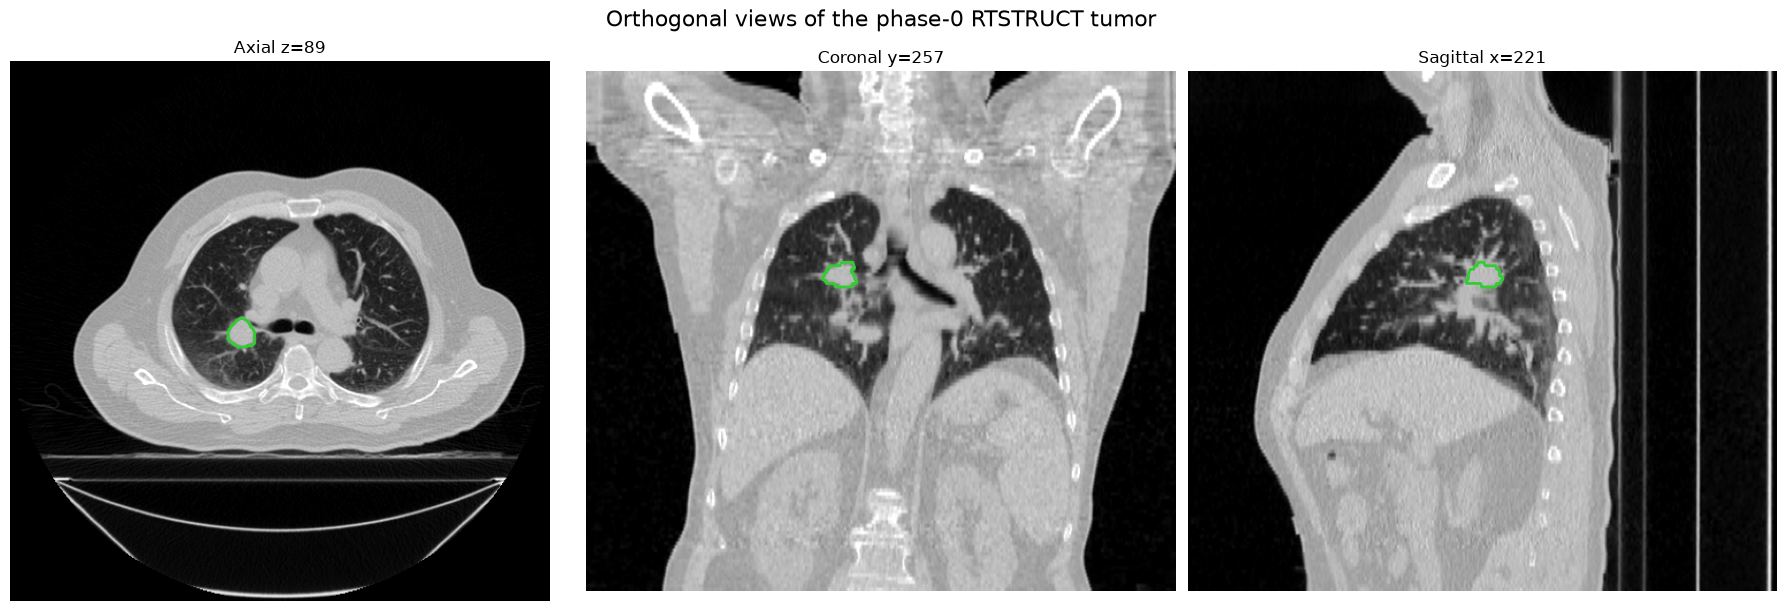

In [7]:
occupied = np.argwhere(mask)

z_mid, y_mid, x_mid = np.round(
    occupied.mean(axis=0)
).astype(int)

spacing_z, spacing_y, spacing_x = (
    geometry.spacing_zyx
)

axial_ct = ct[z_mid]
axial_mask = mask[z_mid]

coronal_ct = np.flipud(
    ct[:, y_mid, :]
)
coronal_mask = np.flipud(
    mask[:, y_mid, :]
)

sagittal_ct = np.flipud(
    ct[:, :, x_mid]
)
sagittal_mask = np.flipud(
    mask[:, :, x_mid]
)

views = [
    (
        axial_ct,
        axial_mask,
        spacing_y / spacing_x,
        f"Axial z={z_mid}",
    ),
    (
        coronal_ct,
        coronal_mask,
        spacing_z / spacing_x,
        f"Coronal y={y_mid}",
    ),
    (
        sagittal_ct,
        sagittal_mask,
        spacing_z / spacing_y,
        f"Sagittal x={x_mid}",
    ),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

for axis, (
    ct_view,
    mask_view,
    aspect,
    title,
) in zip(axes, views):
    axis.imshow(
        window_hu(ct_view),
        cmap="gray",
        aspect=aspect,
        origin="upper",
    )

    axis.contour(
        mask_view,
        levels=[0.5],
        colors=["limegreen"],
        linewidths=2,
    )

    axis.set_title(title)
    axis.set_axis_off()

fig.suptitle(
    "Orthogonal views of the phase-0 RTSTRUCT tumor",
    fontsize=16,
)

plt.show()

## Interactive 3D mesh in patient coordinates [mm]

## 4D CT-derived anatomy with reference and Gaussian-transferred tumor meshes

The phase-specific RTSTRUCT reference is shown in green. The mesh predicted from MedGS4D Gaussian motion is shown in red.

The body, lung, and bone surfaces are threshold-derived anatomical context rather than clinical segmentations.

In [9]:
PHASES = list(range(0, 100, 10))

BODY_THRESHOLD_HU = -700
LUNG_THRESHOLD_HU = -500
BONE_THRESHOLD_HU = 200

BODY_OPACITY = 0.08
LUNG_OPACITY = 0.18
BONE_OPACITY = 0.22
TUMOR_OPACITY = 1.00

BODY_STEP_SIZE = 4
LUNG_STEP_SIZE = 2
BONE_STEP_SIZE = 2

INITIAL_CAMERA = dict(
    eye=dict(
        x=1.55,
        y=-1.35,
        z=0.95,
    ),
    up=dict(
        x=0.0,
        y=0.0,
        z=1.0,
    ),
    center=dict(
        x=0.0,
        y=0.0,
        z=0.0,
    ),
)


def keep_largest_components(
    mask: np.ndarray,
    count: int,
    min_size: int,
) -> np.ndarray:
    labels, component_count = ndi.label(mask)

    if component_count == 0:
        return np.zeros_like(
            mask,
            dtype=bool,
        )

    sizes = np.bincount(labels.ravel())
    sizes[0] = 0

    ordered_labels = np.argsort(
        sizes
    )[::-1]

    selected_labels = [
        int(label)
        for label in ordered_labels
        if sizes[label] >= min_size
    ][:count]

    return np.isin(
        labels,
        selected_labels,
    )


def remove_small_components(
    mask: np.ndarray,
    min_size: int,
) -> np.ndarray:
    labels, component_count = ndi.label(mask)

    if component_count == 0:
        return np.zeros_like(
            mask,
            dtype=bool,
        )

    sizes = np.bincount(labels.ravel())

    keep = sizes >= min_size
    keep[0] = False

    return keep[labels]


def build_body_mask(
    ct_hu: np.ndarray,
) -> np.ndarray:
    body_mask = np.zeros_like(
        ct_hu,
        dtype=bool,
    )

    for z_index, ct_slice in enumerate(ct_hu):
        foreground = (
            ct_slice > BODY_THRESHOLD_HU
        )

        labels, component_count = ndi.label(
            foreground
        )

        if component_count == 0:
            continue

        sizes = np.bincount(
            labels.ravel()
        )
        sizes[0] = 0

        largest_label = int(
            np.argmax(sizes)
        )

        body_slice = (
            labels == largest_label
        )

        body_slice = ndi.binary_closing(
            body_slice,
            structure=np.ones(
                (3, 3),
                dtype=bool,
            ),
        )

        body_slice = ndi.binary_fill_holes(
            body_slice
        )

        body_mask[z_index] = body_slice

    body_mask = ndi.binary_closing(
        body_mask,
        structure=np.ones(
            (3, 3, 3),
            dtype=bool,
        ),
    )

    return body_mask


def mask_to_surface(
    mask: np.ndarray,
    geometry,
    step_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    if not mask.any():
        return (
            np.empty(
                (0, 3),
                dtype=np.float32,
            ),
            np.empty(
                (0, 3),
                dtype=np.int32,
            ),
        )

    padded = np.pad(
        mask.astype(np.uint8),
        1,
        mode="constant",
    )

    vertices_zyx, faces, _, _ = marching_cubes(
        padded,
        level=0.5,
        step_size=step_size,
        allow_degenerate=False,
    )

    vertices_zyx -= 1.0

    vertices_xyz = (
        geometry.index_zyx_to_patient_xyz(
            vertices_zyx
        )
    )

    return (
        vertices_xyz.astype(np.float32),
        faces.astype(np.int32),
    )


@lru_cache(maxsize=10)
def load_phase_surfaces(
    phase: int,
) -> dict:
    phase = int(phase)

    phase_dir = (
        SERIES_DIR
        / f"phase_{phase:02d}"
    )

    ct_hu = np.load(
        phase_dir / "ct_vis_hu.npy",
        allow_pickle=False,
    )

    geometry = load_geometry(
        phase_dir / "ct_vis_geometry.json"
    )

    reference_tumor_mesh = load_mesh_npz(
        phase_dir / "mesh_raw.npz"
    )

    body_mask = build_body_mask(ct_hu)

    lung_candidates = (
        (ct_hu < LUNG_THRESHOLD_HU)
        & body_mask
    )

    lung_mask = keep_largest_components(
        lung_candidates,
        count=3,
        min_size=150,
    )

    lung_mask = ndi.binary_closing(
        lung_mask,
        structure=np.ones(
            (3, 3, 3),
            dtype=bool,
        ),
    )

    bone_mask = (
        (ct_hu > BONE_THRESHOLD_HU)
        & body_mask
    )

    bone_mask = remove_small_components(
        bone_mask,
        min_size=8,
    )

    body_vertices, body_faces = mask_to_surface(
        body_mask,
        geometry,
        step_size=BODY_STEP_SIZE,
    )

    lung_vertices, lung_faces = mask_to_surface(
        lung_mask,
        geometry,
        step_size=LUNG_STEP_SIZE,
    )

    bone_vertices, bone_faces = mask_to_surface(
        bone_mask,
        geometry,
        step_size=BONE_STEP_SIZE,
    )

    return {
        "reference_tumor_mesh": reference_tumor_mesh,
        "body_vertices": body_vertices,
        "body_faces": body_faces,
        "lung_vertices": lung_vertices,
        "lung_faces": lung_faces,
        "bone_vertices": bone_vertices,
        "bone_faces": bone_faces,
    }


def add_mesh_trace(
    figure: go.Figure,
    vertices: np.ndarray,
    faces: np.ndarray,
    *,
    name: str,
    color: str,
    opacity: float,
) -> None:
    if len(vertices) == 0 or len(faces) == 0:
        return

    figure.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            name=name,
            color=color,
            opacity=opacity,
            flatshading=False,
            hoverinfo="skip",
        )
    )


def make_phase_figure(
    phase: int,
) -> go.Figure:
    phase = int(phase)

    data = load_phase_surfaces(phase)

    figure = go.Figure()

    add_mesh_trace(
        figure,
        data["body_vertices"],
        data["body_faces"],
        name="Body surface",
        color="lightgray",
        opacity=BODY_OPACITY,
    )

    add_mesh_trace(
        figure,
        data["lung_vertices"],
        data["lung_faces"],
        name="Lungs",
        color="lightskyblue",
        opacity=LUNG_OPACITY,
    )

    add_mesh_trace(
        figure,
        data["bone_vertices"],
        data["bone_faces"],
        name="Bone",
        color="ivory",
        opacity=BONE_OPACITY,
    )

    reference_tumor_mesh = data[
        "reference_tumor_mesh"
    ]

    add_mesh_trace(
        figure,
        reference_tumor_mesh.vertices_xyz,
        reference_tumor_mesh.faces,
        name=f"RTSTRUCT tumor ﷿﷿﷿ phase {phase}%",
        color="mediumseagreen",
        opacity=TUMOR_OPACITY,
    )

    figure.update_layout(
        title=(
            "CT-derived anatomy and reference tumor mesh "
            f"﷿﷿﷿ phase {phase}%"
        ),
        scene=dict(
            xaxis_title="Patient x [mm]",
            yaxis_title="Patient y [mm]",
            zaxis_title="Patient z [mm]",
            aspectmode="data",
            camera=INITIAL_CAMERA,
        ),
        legend=dict(
            x=0.01,
            y=0.99,
        ),
        margin=dict(
            l=0,
            r=0,
            t=65,
            b=0,
        ),
        width=1050,
        height=850,
    )

    return figure


phase_slider = widgets.SelectionSlider(
    options=PHASES,
    value=50,
    description="Phase [%]",
    continuous_update=False,
    style={
        "description_width": "initial",
    },
    layout=widgets.Layout(
        width="650px",
    ),
)

phase_output = widgets.Output()


def refresh_phase(
    change=None,
) -> None:
    with phase_output:
        phase_output.clear_output(
            wait=True
        )

        figure = make_phase_figure(
            int(phase_slider.value)
        )

        figure.show()


phase_slider.observe(
    refresh_phase,
    names="value",
)

display(
    widgets.VBox(
        [
            phase_slider,
            phase_output,
        ]
    )
)

refresh_phase()

## Round-trip mismatch

In [10]:
difference = np.logical_xor(mask, roundtrip)
difference_areas = difference.reshape(difference.shape[0], -1).sum(axis=1)

if not difference.any():
    print("No round-trip mismatch: source and reconstructed masks are identical.")
else:
    worst_slice = int(np.argmax(difference_areas))

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6),
        constrained_layout=True,
    )

    axes[0].imshow(mask[worst_slice], cmap="gray")
    axes[0].set_title("Source mask")

    axes[1].imshow(roundtrip[worst_slice], cmap="gray")
    axes[1].set_title("Mesh ﷿﷿﷿ mask")

    axes[2].imshow(difference[worst_slice], cmap="gray")
    axes[2].set_title(
        f"XOR mismatch, slice {worst_slice}"
    )

    for axis in axes:
        axis.set_axis_off()

    plt.show()

No round-trip mismatch: source and reconstructed masks are identical.


## Gaussian-to-mesh transfer experiment

This section loads the artifacts produced by:

- `scripts/inspect_gaussian_geometry.py`
- `scripts/predict_mesh_from_gaussians.py`

The notebook does not recompute the Gaussian deformation field or mesh evaluation. It only visualizes the saved geometry validation, metrics, and predicted mesh series.

In [11]:
STUDY_NAME = SERIES_DIR.parents[1].name

STACK_ROOT = next(
    parent
    for parent in SERIES_DIR.parents
    if (parent / "data").is_dir()
    and (parent / "results").is_dir()
)

MEDGS4D_RESULTS_ROOT = (
    STACK_ROOT
    / "results"
    / "medgs4d"
    / STUDY_NAME
)

prediction_files = sorted(
    MEDGS4D_RESULTS_ROOT.glob(
        "*/evaluation/mesh_transfer/iter_*/predictions.npz"
    )
)

assert len(prediction_files) == 1, (
    "Expected exactly one evaluated mesh-transfer run, found:\n"
    + "\n".join(str(path) for path in prediction_files)
)

predictions_path = prediction_files[0]

MESH_TRANSFER_DIR = predictions_path.parent
RUN_DIR = MESH_TRANSFER_DIR.parents[2]

GAUSSIAN_GEOMETRY_DIR = (
    RUN_DIR
    / "evaluation"
    / "gaussian_geometry"
    / MESH_TRANSFER_DIR.name
)

gaussian_geometry_summary = json.loads(
    (
        GAUSSIAN_GEOMETRY_DIR
        / "summary.json"
    ).read_text(encoding="utf-8")
)

mesh_transfer_summary = json.loads(
    (
        MESH_TRANSFER_DIR
        / "summary.json"
    ).read_text(encoding="utf-8")
)

transfer_metrics = pd.read_csv(
    MESH_TRANSFER_DIR / "per_phase.csv"
)

predictions = np.load(
    predictions_path,
    allow_pickle=False,
)

prediction_phases = predictions[
    "phases"
].astype(int)

predicted_vertices_xyz = predictions[
    "vertices_xyz_mm"
]

predicted_displacements_xyz = predictions[
    "vertex_displacement_xyz_mm"
]

prediction_faces = predictions["faces"]

phase_to_prediction_index = {
    int(phase): index
    for index, phase in enumerate(prediction_phases)
}

print(f"Study: {STUDY_NAME}")
print(f"Stack root: {STACK_ROOT}")
print(f"Run directory: {RUN_DIR}")
print(f"Geometry directory: {GAUSSIAN_GEOMETRY_DIR}")
print(f"Transfer directory: {MESH_TRANSFER_DIR}")
print(f"Evaluated phases: {prediction_phases.tolist()}")
print(f"Predicted vertices: {predicted_vertices_xyz.shape}")
print(f"Faces: {prediction_faces.shape}")

Study: patient117_20001024_annotated
Stack root: /home/jovyan/shared/mtm_medgs_stack
Run directory: /home/jovyan/shared/mtm_medgs_stack/results/medgs4d/patient117_20001024_annotated/phase00_canon15000_denoised_holdout_iter7000
Geometry directory: /home/jovyan/shared/mtm_medgs_stack/results/medgs4d/patient117_20001024_annotated/phase00_canon15000_denoised_holdout_iter7000/evaluation/gaussian_geometry/iter_007000
Transfer directory: /home/jovyan/shared/mtm_medgs_stack/results/medgs4d/patient117_20001024_annotated/phase00_canon15000_denoised_holdout_iter7000/evaluation/mesh_transfer/iter_007000
Evaluated phases: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
Predicted vertices: (10, 2199, 3)
Faces: (4398, 3)


### MedGS-to-DICOM spatial alignment

The blue points are Gaussian centers projected onto selected axial CT slices. The red contour is the phase-0 RTSTRUCT tumor annotation.

This visualization verifies the orientation, scale, and spatial alignment between MedGS coordinates and DICOM patient coordinates.

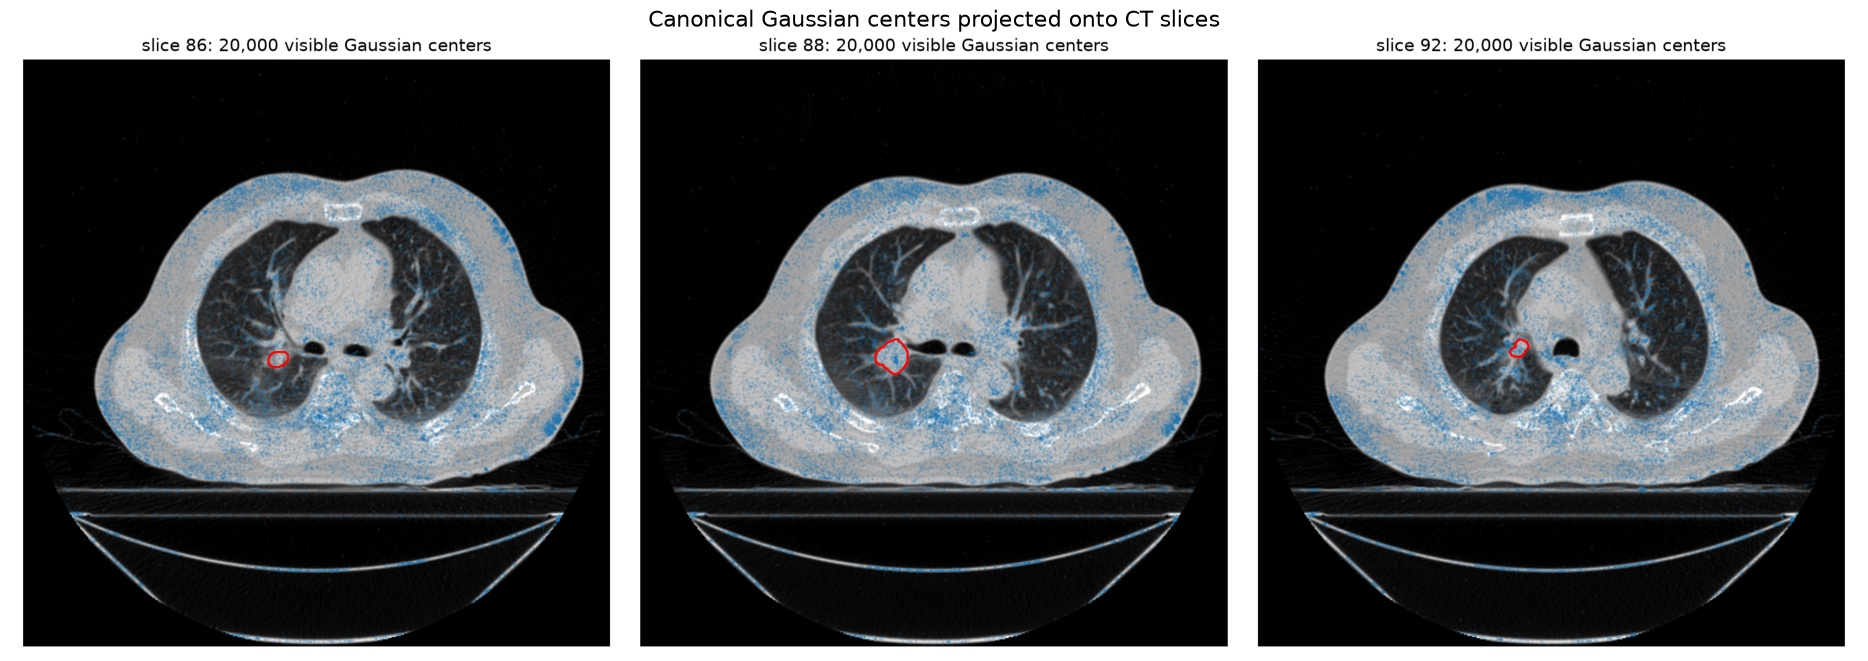

In [12]:
projection_overlay = plt.imread(
    GAUSSIAN_GEOMETRY_DIR / "projection_overlay.png"
)

plt.figure(figsize=(24, 8))
plt.imshow(projection_overlay)
plt.axis("off")
plt.title(
    "Canonical Gaussian centers projected onto CT slices",
    fontsize=16,
)
plt.show()

### Gaussian neighborhood around the canonical tumor

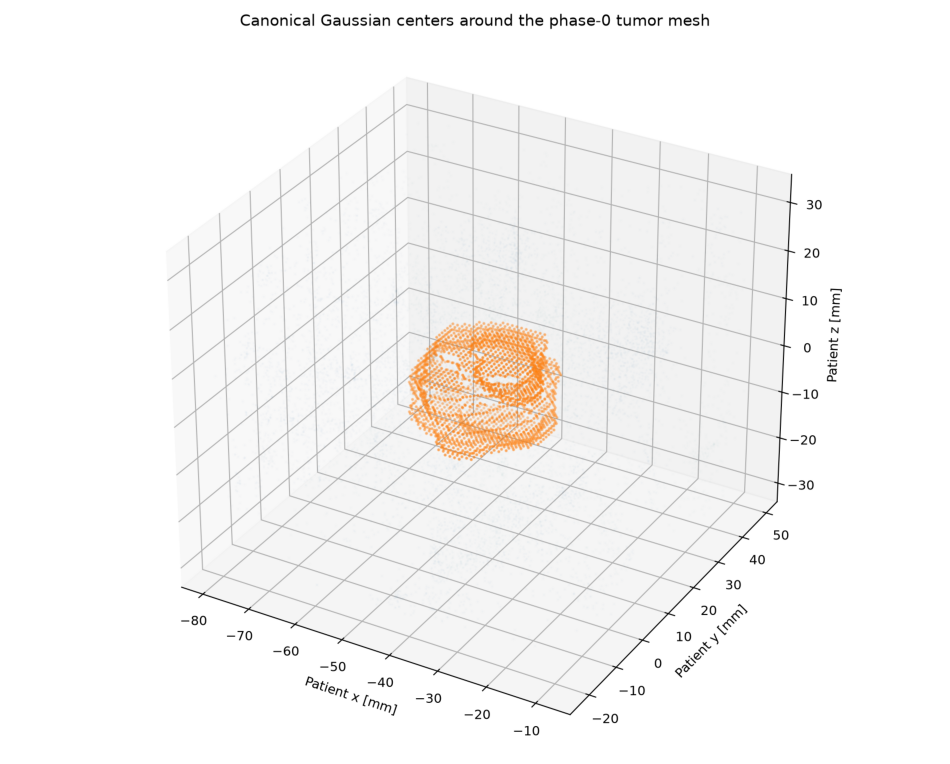

In [13]:
tumor_neighborhood = plt.imread(
    GAUSSIAN_GEOMETRY_DIR
    / "tumor_neighborhood_overview.png"
)

plt.figure(figsize=(12, 10))
plt.imshow(tumor_neighborhood)
plt.axis("off")
plt.show()

In [14]:
geometry_report = pd.DataFrame(
    {
        "Value": {
            "Gaussian count": (
                gaussian_geometry_summary["GaussianCount"]
            ),
            "Gaussians inside CT volume": (
                gaussian_geometry_summary[
                    "InsideVolumeGaussianFraction"
                ]
            ),
            "Mesh round-trip mean error [mm]": (
                gaussian_geometry_summary[
                    "MeshPatientRoundtripMeanErrorMm"
                ]
            ),
            "Mesh round-trip maximum error [mm]": (
                gaussian_geometry_summary[
                    "MeshPatientRoundtripMaximumErrorMm"
                ]
            ),
            "Nearest Gaussian mean distance [mm]": (
                gaussian_geometry_summary[
                    "NearestGaussianDistanceMmMean"
                ]
            ),
            "Nearest Gaussian median distance [mm]": (
                gaussian_geometry_summary[
                    "NearestGaussianDistanceMmMedian"
                ]
            ),
            "Nearest Gaussian p95 distance [mm]": (
                gaussian_geometry_summary[
                    "NearestGaussianDistanceMmP95"
                ]
            ),
            "16th Gaussian median distance [mm]": (
                gaussian_geometry_summary[
                    "KthGaussianDistanceMmMedian"
                ]
            ),
            "16th Gaussian p95 distance [mm]": (
                gaussian_geometry_summary[
                    "KthGaussianDistanceMmP95"
                ]
            ),
        }
    }
)

display(
    geometry_report.style.format(
        {
            "Value": lambda value: (
                f"{value:,.4f}"
                if isinstance(value, float)
                else f"{value:,}"
            )
        }
    )
)

,Value
Gaussian count,"611,563.0000"
Gaussians inside CT volume,0.9920
Mesh round-trip mean error [mm],0.0000
Mesh round-trip maximum error [mm],0.0000
Nearest Gaussian mean distance [mm],2.0071
Nearest Gaussian median distance [mm],1.9321
Nearest Gaussian p95 distance [mm],3.5754
16th Gaussian median distance [mm],4.5235
16th Gaussian p95 distance [mm],6.3568


### Gaussian-to-mesh transfer metrics

The static baseline uses the unchanged phase-0 tumor mesh for every respiratory phase.

The Gaussian-transfer result deforms the phase-0 mesh using the local MedGS4D Gaussian motion while preserving mesh topology.

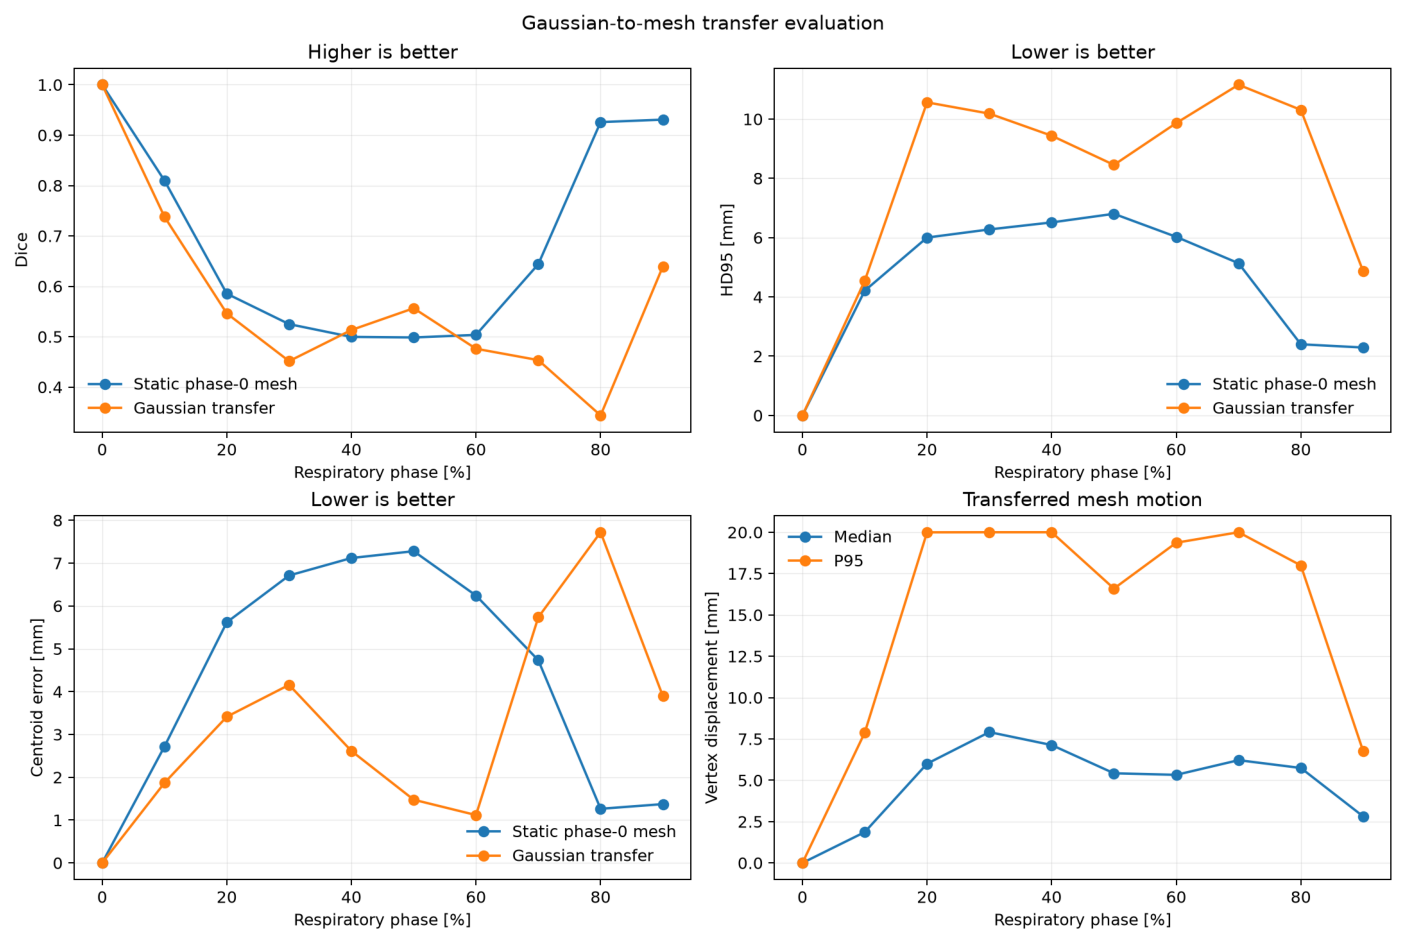

In [15]:
metrics_image = plt.imread(
    MESH_TRANSFER_DIR / "metrics.png"
)

plt.figure(figsize=(18, 12))
plt.imshow(metrics_image)
plt.axis("off")
plt.show()

In [16]:
metric_columns = [
    "PhasePercent",
    "Split",
    "GlobalInlierGaussianFraction",
    "VertexDisplacementMmMedian",
    "VertexDisplacementMmP95",
    "BaselineDice",
    "PredictedDice",
    "DiceImprovement",
    "BaselineHD95Mm",
    "PredictedHD95Mm",
    "HD95ReductionMm",
    "BaselineCentroidErrorMm",
    "PredictedCentroidErrorMm",
    "PredictedVolumeErrorPercent",
]

metric_table = transfer_metrics[metric_columns].copy()

display(
    metric_table.style.format(
        {
            "PhasePercent": "{:.0f}",
            "GlobalInlierGaussianFraction": "{:.3f}",
            "VertexDisplacementMmMedian": "{:.2f}",
            "VertexDisplacementMmP95": "{:.2f}",
            "BaselineDice": "{:.3f}",
            "PredictedDice": "{:.3f}",
            "DiceImprovement": "{:+.3f}",
            "BaselineHD95Mm": "{:.2f}",
            "PredictedHD95Mm": "{:.2f}",
            "HD95ReductionMm": "{:+.2f}",
            "BaselineCentroidErrorMm": "{:.2f}",
            "PredictedCentroidErrorMm": "{:.2f}",
            "PredictedVolumeErrorPercent": "{:+.1f}",
        }
    )
)

,PhasePercent,Split,GlobalInlierGaussianFraction,VertexDisplacementMmMedian,VertexDisplacementMmP95,BaselineDice,PredictedDice,DiceImprovement,BaselineHD95Mm,PredictedHD95Mm,HD95ReductionMm,BaselineCentroidErrorMm,PredictedCentroidErrorMm,PredictedVolumeErrorPercent
0,0,canonical,1.000,0.00,0.00,1.000,1.000,+0.000,0.00,0.00,+0.00,0.00,0.00,+0.0
1,10,validation,0.737,1.86,7.88,0.810,0.738,-0.072,4.21,4.54,-0.34,2.72,1.87,-20.4
2,20,train,0.720,6.00,19.99,0.585,0.546,-0.039,6.00,10.56,-4.56,5.62,3.41,-48.5
3,30,validation,0.714,7.91,20.00,0.525,0.451,-0.073,6.28,10.18,-3.91,6.71,4.16,-46.8
4,40,train,0.724,7.13,20.00,0.500,0.513,+0.014,6.51,9.44,-2.93,7.12,2.61,-48.3
5,50,validation,0.734,5.42,16.59,0.498,0.556,+0.058,6.80,8.45,-1.65,7.28,1.48,-41.0
6,60,train,0.717,5.33,19.37,0.504,0.476,-0.027,6.03,9.87,-3.84,6.24,1.12,-41.4
7,70,validation,0.701,6.21,20.00,0.644,0.453,-0.190,5.14,11.16,-6.02,4.73,5.74,-48.4
8,80,train,0.721,5.74,17.99,0.926,0.344,-0.582,2.40,10.31,-7.91,1.26,7.72,-40.5
9,90,validation,0.760,2.81,6.76,0.931,0.639,-0.291,2.29,4.86,-2.57,1.37,3.89,-14.5


In [17]:
summary_rows = []

all_noncanonical = mesh_transfer_summary["AllNoncanonical"]

summary_rows.append(
    {
        "Subset": "All noncanonical",
        "Phase count": all_noncanonical["PhaseCount"],
        "Baseline Dice": all_noncanonical["BaselineDice"],
        "Predicted Dice": all_noncanonical["PredictedDice"],
        "Dice change": all_noncanonical["DiceImprovement"],
        "Baseline HD95 [mm]": all_noncanonical["BaselineHD95Mm"],
        "Predicted HD95 [mm]": all_noncanonical["PredictedHD95Mm"],
        "HD95 reduction [mm]": all_noncanonical[
            "HD95MmReduction"
        ],
        "Baseline centroid error [mm]": all_noncanonical[
            "BaselineCentroidErrorMm"
        ],
        "Predicted centroid error [mm]": all_noncanonical[
            "PredictedCentroidErrorMm"
        ],
    }
)

for split, values in mesh_transfer_summary["BySplit"].items():
    summary_rows.append(
        {
            "Subset": split,
            "Phase count": values["PhaseCount"],
            "Baseline Dice": values["BaselineDice"],
            "Predicted Dice": values["PredictedDice"],
            "Dice change": values["DiceImprovement"],
            "Baseline HD95 [mm]": values["BaselineHD95Mm"],
            "Predicted HD95 [mm]": values["PredictedHD95Mm"],
            "HD95 reduction [mm]": values["HD95MmReduction"],
            "Baseline centroid error [mm]": values[
                "BaselineCentroidErrorMm"
            ],
            "Predicted centroid error [mm]": values[
                "PredictedCentroidErrorMm"
            ],
        }
    )

summary_table = pd.DataFrame(summary_rows)

display(
    summary_table.style.format(
        {
            "Baseline Dice": "{:.3f}",
            "Predicted Dice": "{:.3f}",
            "Dice change": "{:+.3f}",
            "Baseline HD95 [mm]": "{:.2f}",
            "Predicted HD95 [mm]": "{:.2f}",
            "HD95 reduction [mm]": "{:+.2f}",
            "Baseline centroid error [mm]": "{:.2f}",
            "Predicted centroid error [mm]": "{:.2f}",
        }
    )
)

,Subset,Phase count,Baseline Dice,Predicted Dice,Dice change,Baseline HD95 [mm],Predicted HD95 [mm],HD95 reduction [mm],Baseline centroid error [mm],Predicted centroid error [mm]
0,All noncanonical,9,0.658,0.524,-0.134,5.07,8.82,-3.75,4.78,3.56
1,canonical,1,1.000,1.000,+0.000,0.00,0.00,+0.00,0.00,0.00
2,train,4,0.629,0.470,-0.159,5.24,10.04,-4.81,5.06,3.72
3,validation,5,0.682,0.568,-0.114,4.94,7.84,-2.90,4.56,3.43


### Phase-by-phase pre-rendered comparison

Blue: static phase-0 mesh.  
Green: phase-specific RTSTRUCT reference.  
Red: Gaussian-transferred prediction.

In [18]:
transfer_comparison_slider = widgets.SelectionSlider(
    options=prediction_phases.tolist(),
    value=50,
    description="Phase [%]",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="650px"),
)

transfer_comparison_output = widgets.Output()


def show_transfer_comparison(change=None) -> None:
    phase = int(transfer_comparison_slider.value)

    image_path = (
        MESH_TRANSFER_DIR
        / "comparisons"
        / f"phase_{phase:02d}.png"
    )

    image = plt.imread(image_path)

    with transfer_comparison_output:
        transfer_comparison_output.clear_output(wait=True)

        plt.figure(figsize=(11, 10))
        plt.imshow(image)
        plt.axis("off")
        plt.show()


transfer_comparison_slider.observe(
    show_transfer_comparison,
    names="value",
)

display(
    widgets.VBox(
        [
            transfer_comparison_slider,
            transfer_comparison_output,
        ]
    )
)

show_transfer_comparison()

### Interactive 3D comparison

The visualization uses the same camera and axis limits for every phase:

- canonical phase-0 mesh,
- phase-specific RTSTRUCT reference,
- Gaussian-transferred prediction.

In [19]:
canonical_transfer_mesh = load_mesh_npz(
    SERIES_DIR / "phase_00" / "mesh_raw.npz"
)

reference_meshes = {
    phase: load_mesh_npz(
        SERIES_DIR
        / f"phase_{phase:02d}"
        / "mesh_raw.npz"
    )
    for phase in prediction_phases
}

phase_to_prediction_index = {
    int(phase): index
    for index, phase in enumerate(prediction_phases)
}

all_mesh_points = [
    canonical_transfer_mesh.vertices_xyz,
    predicted_vertices_xyz.reshape(-1, 3),
]

all_mesh_points.extend(
    reference_mesh.vertices_xyz
    for reference_mesh in reference_meshes.values()
)

all_mesh_points = np.concatenate(
    all_mesh_points,
    axis=0,
)

plot_minimum = all_mesh_points.min(axis=0)
plot_maximum = all_mesh_points.max(axis=0)
plot_margin = 0.05 * (plot_maximum - plot_minimum)

plot_minimum -= plot_margin
plot_maximum += plot_margin


def make_transfer_3d_figure(phase: int) -> go.Figure:
    phase = int(phase)
    prediction_index = phase_to_prediction_index[phase]

    reference_mesh = reference_meshes[phase]
    predicted_vertices = predicted_vertices_xyz[
        prediction_index
    ]

    figure = go.Figure()

    add_mesh_trace(
        figure,
        canonical_transfer_mesh.vertices_xyz,
        canonical_transfer_mesh.faces,
        name="Canonical phase 0",
        color="lightskyblue",
        opacity=0.18,
    )

    add_mesh_trace(
        figure,
        reference_mesh.vertices_xyz,
        reference_mesh.faces,
        name=f"RTSTRUCT phase {phase}",
        color="mediumseagreen",
        opacity=0.40,
    )

    add_mesh_trace(
        figure,
        predicted_vertices,
        prediction_faces,
        name="Gaussian prediction",
        color="crimson",
        opacity=0.55,
    )

    phase_metrics = transfer_metrics.loc[
        transfer_metrics["PhasePercent"] == phase
    ].iloc[0]

    figure.update_layout(
        title=(
            f"Gaussian-to-mesh transfer ﷿﷿﷿ phase {phase}%"
            "<br><sup>"
            f"Dice: {phase_metrics['BaselineDice']:.3f} ﷿﷿﷿ "
            f"{phase_metrics['PredictedDice']:.3f}; "
            f"HD95: {phase_metrics['BaselineHD95Mm']:.2f} ﷿﷿﷿ "
            f"{phase_metrics['PredictedHD95Mm']:.2f} mm"
            "</sup>"
        ),
        scene=dict(
            xaxis=dict(
                title="Patient x [mm]",
                range=[
                    plot_minimum[0],
                    plot_maximum[0],
                ],
            ),
            yaxis=dict(
                title="Patient y [mm]",
                range=[
                    plot_minimum[1],
                    plot_maximum[1],
                ],
            ),
            zaxis=dict(
                title="Patient z [mm]",
                range=[
                    plot_minimum[2],
                    plot_maximum[2],
                ],
            ),
            aspectmode="data",
            camera=INITIAL_CAMERA,
        ),
        legend=dict(
            x=0.01,
            y=0.99,
        ),
        margin=dict(
            l=0,
            r=0,
            t=80,
            b=0,
        ),
        width=1000,
        height=820,
    )

    return figure

In [20]:
transfer_3d_slider = widgets.SelectionSlider(
    options=prediction_phases.tolist(),
    value=50,
    description="Phase [%]",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="650px"),
)

transfer_3d_output = widgets.Output()


def refresh_transfer_3d(change=None) -> None:
    phase = int(transfer_3d_slider.value)

    with transfer_3d_output:
        transfer_3d_output.clear_output(wait=True)

        figure = make_transfer_3d_figure(phase)
        figure.show()


transfer_3d_slider.observe(
    refresh_transfer_3d,
    names="value",
)

display(
    widgets.VBox(
        [
            transfer_3d_slider,
            transfer_3d_output,
        ]
    )
)

refresh_transfer_3d()

# Plots with tumor 

In [21]:
# Cell-level defaults.
AXIAL_SHOW_REFERENCE_DEFAULT = True
AXIAL_SHOW_PREDICTION_DEFAULT = True

# The previous display orientation was vertically inverted.
AXIAL_FLIP_VERTICAL = True


def show_phase_axial_projections(
    phase: int,
    *,
    show_reference: bool,
    show_prediction: bool,
) -> None:
    phase = int(phase)

    phase_case = load_phase_case(phase)
    phase_ct = phase_case["ct_volume"]
    reference_mask = phase_case["mask"]
    predicted_mask = predicted_mask_for_phase(phase)

    combined_mask = reference_mask | predicted_mask

    areas = combined_mask.reshape(
        combined_mask.shape[0],
        -1,
    ).sum(axis=1)

    occupied_slices = np.flatnonzero(areas)

    selected_slices = [
        int(occupied_slices[0]),
        int(np.argmax(areas)),
        int(occupied_slices[-1]),
    ]

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(20, 7),
    )

    figure.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.13,
        top=0.86,
        wspace=0.03,
    )

    for axis, slice_index in zip(
        axes,
        selected_slices,
    ):
        near_slice = (
            np.abs(
                canonical_gaussian_index_zyx[:, 0]
                - slice_index
            )
            <= 0.75
        )

        gaussian_points = (
            canonical_gaussian_index_zyx[near_slice]
        ).copy()

        ct_view = window_hu(
            phase_ct[slice_index]
        )

        reference_view = reference_mask[
            slice_index
        ]

        prediction_view = predicted_mask[
            slice_index
        ]

        if AXIAL_FLIP_VERTICAL:
            ct_view = np.flipud(ct_view)
            reference_view = np.flipud(reference_view)
            prediction_view = np.flipud(prediction_view)

            gaussian_points[:, 1] = (
                phase_ct.shape[1]
                - 1
                - gaussian_points[:, 1]
            )

        axis.imshow(
            ct_view,
            cmap="gray",
            origin="upper",
        )

        axis.scatter(
            gaussian_points[:, 2],
            gaussian_points[:, 1],
            s=1.2,
            alpha=0.18,
            color=GAUSSIAN_COLOR,
        )

        if show_reference and reference_view.any():
            axis.contour(
                reference_view,
                levels=[0.5],
                colors=[REFERENCE_COLOR],
                linewidths=2.0,
            )

        if show_prediction and prediction_view.any():
            axis.contour(
                prediction_view,
                levels=[0.5],
                colors=[PREDICTION_COLOR],
                linewidths=2.0,
            )

        axis.set_title(
            f"Slice {slice_index}: "
            f"{len(gaussian_points):,} sampled Gaussian centers"
        )

        axis.set_xlim(
            0,
            phase_ct.shape[2] - 1,
        )
        axis.set_ylim(
            phase_ct.shape[1] - 1,
            0,
        )

        axis.set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=".",
            linestyle="none",
            markersize=8,
            color=GAUSSIAN_COLOR,
            label="Canonical Gaussian sample",
        ),
    ]

    if show_reference:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=REFERENCE_COLOR,
                linewidth=2,
                label="RTSTRUCT reference",
            )
        )

    if show_prediction:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=PREDICTION_COLOR,
                linewidth=2,
                label="Gaussian-transferred mesh",
            )
        )

    figure.suptitle(
        (
            "CT, canonical Gaussian centers, and tumor contours "
            f"﷿﷿﷿ phase {phase}%"
        ),
        fontsize=16,
        y=0.97,
    )

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=len(legend_handles),
        frameon=False,
    )

    plt.show()


axial_phase_slider = widgets.SelectionSlider(
    options=prediction_phases.tolist(),
    value=50,
    description="Phase [%]",
    continuous_update=False,
    style={
        "description_width": "initial",
    },
    layout=widgets.Layout(
        width="650px",
    ),
)

axial_reference_checkbox = widgets.Checkbox(
    value=AXIAL_SHOW_REFERENCE_DEFAULT,
    description="RTSTRUCT reference",
    indent=False,
)

axial_prediction_checkbox = widgets.Checkbox(
    value=AXIAL_SHOW_PREDICTION_DEFAULT,
    description="Gaussian prediction",
    indent=False,
)

axial_output = widgets.Output()


def refresh_axial_projections(change=None) -> None:
    with axial_output:
        axial_output.clear_output(wait=True)

        show_phase_axial_projections(
            int(axial_phase_slider.value),
            show_reference=(
                axial_reference_checkbox.value
            ),
            show_prediction=(
                axial_prediction_checkbox.value
            ),
        )


axial_phase_slider.observe(
    refresh_axial_projections,
    names="value",
)

axial_reference_checkbox.observe(
    refresh_axial_projections,
    names="value",
)

axial_prediction_checkbox.observe(
    refresh_axial_projections,
    names="value",
)

display(
    widgets.VBox(
        [
            axial_phase_slider,
            widgets.HBox(
                [
                    axial_reference_checkbox,
                    axial_prediction_checkbox,
                ],
                layout=widgets.Layout(
                    gap="25px",
                ),
            ),
            axial_output,
        ]
    )
)

refresh_axial_projections()

In [22]:
# Cell-level defaults.
ORTHOGONAL_SHOW_REFERENCE_DEFAULT = True
ORTHOGONAL_SHOW_PREDICTION_DEFAULT = True

# Coronal and sagittal arrays have patient z on their vertical axis.
# Flip only their display orientation.
ORTHOGONAL_FLIP_Z = True


def show_phase_orthogonal_views(
    phase: int,
    *,
    show_reference: bool,
    show_prediction: bool,
) -> None:
    phase = int(phase)

    phase_case = load_phase_case(phase)

    phase_ct = phase_case["ct_volume"]
    reference_mask = phase_case["mask"]
    predicted_mask = predicted_mask_for_phase(phase)
    phase_geometry = phase_case["geometry"]

    combined_mask = reference_mask | predicted_mask
    occupied = np.argwhere(combined_mask)

    z_mid, y_mid, x_mid = np.round(
        occupied.mean(axis=0)
    ).astype(int)

    spacing_z, spacing_y, spacing_x = (
        phase_geometry.spacing_zyx
    )

    # Axial: rows correspond to y, columns to x.
    axial_ct = phase_ct[z_mid]
    axial_reference = reference_mask[z_mid]
    axial_prediction = predicted_mask[z_mid]

    # Coronal: rows correspond to z, columns to x.
    coronal_ct = phase_ct[:, y_mid, :]
    coronal_reference = reference_mask[:, y_mid, :]
    coronal_prediction = predicted_mask[:, y_mid, :]

    # Sagittal: rows correspond to z, columns to y.
    sagittal_ct = phase_ct[:, :, x_mid]
    sagittal_reference = reference_mask[:, :, x_mid]
    sagittal_prediction = predicted_mask[:, :, x_mid]

    if ORTHOGONAL_FLIP_Z:
        coronal_ct = np.flipud(coronal_ct)
        coronal_reference = np.flipud(
            coronal_reference
        )
        coronal_prediction = np.flipud(
            coronal_prediction
        )

        sagittal_ct = np.flipud(sagittal_ct)
        sagittal_reference = np.flipud(
            sagittal_reference
        )
        sagittal_prediction = np.flipud(
            sagittal_prediction
        )

    views = [
        (
            axial_ct,
            axial_reference,
            axial_prediction,
            spacing_y / spacing_x,
            f"Axial z={z_mid}",
        ),
        (
            coronal_ct,
            coronal_reference,
            coronal_prediction,
            spacing_z / spacing_x,
            f"Coronal y={y_mid}",
        ),
        (
            sagittal_ct,
            sagittal_reference,
            sagittal_prediction,
            spacing_z / spacing_y,
            f"Sagittal x={x_mid}",
        ),
    ]

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(19, 7),
    )

    figure.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.13,
        top=0.84,
        wspace=0.04,
    )

    for axis, (
        ct_view,
        reference_view,
        prediction_view,
        aspect,
        title,
    ) in zip(axes, views):
        axis.imshow(
            window_hu(ct_view),
            cmap="gray",
            aspect=aspect,
            origin="upper",
        )

        if show_reference and reference_view.any():
            axis.contour(
                reference_view,
                levels=[0.5],
                colors=[REFERENCE_COLOR],
                linewidths=2.0,
            )

        if show_prediction and prediction_view.any():
            axis.contour(
                prediction_view,
                levels=[0.5],
                colors=[PREDICTION_COLOR],
                linewidths=2.0,
            )

        axis.set_title(title)
        axis.set_axis_off()

    legend_handles = []

    if show_reference:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=REFERENCE_COLOR,
                linewidth=2,
                label="RTSTRUCT reference",
            )
        )

    if show_prediction:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=PREDICTION_COLOR,
                linewidth=2,
                label="Gaussian-transferred mesh",
            )
        )

    figure.suptitle(
        f"Orthogonal tumor comparison ﷿﷿﷿ phase {phase}%",
        fontsize=16,
        y=0.97,
    )

    if legend_handles:
        figure.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.015),
            ncol=len(legend_handles),
            frameon=False,
        )

    plt.show()


orthogonal_phase_slider = widgets.SelectionSlider(
    options=prediction_phases.tolist(),
    value=50,
    description="Phase [%]",
    continuous_update=False,
    style={
        "description_width": "initial",
    },
    layout=widgets.Layout(
        width="650px",
    ),
)

orthogonal_reference_checkbox = widgets.Checkbox(
    value=ORTHOGONAL_SHOW_REFERENCE_DEFAULT,
    description="RTSTRUCT reference",
    indent=False,
)

orthogonal_prediction_checkbox = widgets.Checkbox(
    value=ORTHOGONAL_SHOW_PREDICTION_DEFAULT,
    description="Gaussian prediction",
    indent=False,
)

orthogonal_output = widgets.Output()


def refresh_orthogonal_views(
    change=None,
) -> None:
    with orthogonal_output:
        orthogonal_output.clear_output(
            wait=True
        )

        show_phase_orthogonal_views(
            int(orthogonal_phase_slider.value),
            show_reference=(
                orthogonal_reference_checkbox.value
            ),
            show_prediction=(
                orthogonal_prediction_checkbox.value
            ),
        )


orthogonal_phase_slider.observe(
    refresh_orthogonal_views,
    names="value",
)

orthogonal_reference_checkbox.observe(
    refresh_orthogonal_views,
    names="value",
)

orthogonal_prediction_checkbox.observe(
    refresh_orthogonal_views,
    names="value",
)

display(
    widgets.VBox(
        [
            orthogonal_phase_slider,
            widgets.HBox(
                [
                    orthogonal_reference_checkbox,
                    orthogonal_prediction_checkbox,
                ],
                layout=widgets.Layout(
                    gap="25px",
                ),
            ),
            orthogonal_output,
        ]
    )
)

refresh_orthogonal_views()

In [23]:
PHASES = prediction_phases.tolist()

BODY_THRESHOLD_HU = -700
LUNG_THRESHOLD_HU = -500
BONE_THRESHOLD_HU = 200

BODY_OPACITY = 0.08
LUNG_OPACITY = 0.18
BONE_OPACITY = 0.22

REFERENCE_TUMOR_OPACITY = 0.78
PREDICTED_TUMOR_OPACITY = 0.62

BODY_STEP_SIZE = 4
LUNG_STEP_SIZE = 2
BONE_STEP_SIZE = 2


# Cell-level defaults.
SHOW_ANATOMY_DEFAULT = True
SHOW_REFERENCE_TUMOR_DEFAULT = True
SHOW_PREDICTED_TUMOR_DEFAULT = True


INITIAL_CAMERA = dict(
    eye=dict(
        x=1.55,
        y=-1.35,
        z=0.95,
    ),
    up=dict(
        x=0.0,
        y=0.0,
        z=1.0,
    ),
    center=dict(
        x=0.0,
        y=0.0,
        z=0.0,
    ),
)


def keep_largest_components(
    mask: np.ndarray,
    count: int,
    min_size: int,
) -> np.ndarray:
    labels, component_count = ndi.label(mask)

    if component_count == 0:
        return np.zeros_like(
            mask,
            dtype=bool,
        )

    sizes = np.bincount(labels.ravel())
    sizes[0] = 0

    ordered_labels = np.argsort(
        sizes
    )[::-1]

    selected_labels = [
        int(label)
        for label in ordered_labels
        if sizes[label] >= min_size
    ][:count]

    return np.isin(
        labels,
        selected_labels,
    )


def remove_small_components(
    mask: np.ndarray,
    min_size: int,
) -> np.ndarray:
    labels, component_count = ndi.label(mask)

    if component_count == 0:
        return np.zeros_like(
            mask,
            dtype=bool,
        )

    sizes = np.bincount(labels.ravel())

    keep = sizes >= min_size
    keep[0] = False

    return keep[labels]


def build_body_mask(
    ct_hu: np.ndarray,
) -> np.ndarray:
    body_mask = np.zeros_like(
        ct_hu,
        dtype=bool,
    )

    for z_index, ct_slice in enumerate(ct_hu):
        foreground = (
            ct_slice > BODY_THRESHOLD_HU
        )

        labels, component_count = ndi.label(
            foreground
        )

        if component_count == 0:
            continue

        sizes = np.bincount(
            labels.ravel()
        )
        sizes[0] = 0

        largest_label = int(
            np.argmax(sizes)
        )

        body_slice = (
            labels == largest_label
        )

        body_slice = ndi.binary_closing(
            body_slice,
            structure=np.ones(
                (3, 3),
                dtype=bool,
            ),
        )

        body_slice = ndi.binary_fill_holes(
            body_slice
        )

        body_mask[z_index] = body_slice

    body_mask = ndi.binary_closing(
        body_mask,
        structure=np.ones(
            (3, 3, 3),
            dtype=bool,
        ),
    )

    return body_mask


def mask_to_surface(
    mask: np.ndarray,
    geometry,
    step_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    if not mask.any():
        return (
            np.empty(
                (0, 3),
                dtype=np.float32,
            ),
            np.empty(
                (0, 3),
                dtype=np.int32,
            ),
        )

    padded = np.pad(
        mask.astype(np.uint8),
        1,
        mode="constant",
    )

    vertices_zyx, faces, _, _ = marching_cubes(
        padded,
        level=0.5,
        step_size=step_size,
        allow_degenerate=False,
    )

    vertices_zyx -= 1.0

    vertices_xyz = (
        geometry.index_zyx_to_patient_xyz(
            vertices_zyx
        )
    )

    return (
        vertices_xyz.astype(np.float32),
        faces.astype(np.int32),
    )


@lru_cache(maxsize=10)
def load_phase_surfaces(
    phase: int,
) -> dict:
    phase = int(phase)

    phase_dir = (
        SERIES_DIR
        / f"phase_{phase:02d}"
    )

    ct_hu = np.load(
        phase_dir / "ct_vis_hu.npy",
        allow_pickle=False,
    )

    geometry = load_geometry(
        phase_dir / "ct_vis_geometry.json"
    )

    tumor_mesh = load_mesh_npz(
        phase_dir / "mesh_raw.npz"
    )

    body_mask = build_body_mask(ct_hu)

    lung_candidates = (
        (ct_hu < LUNG_THRESHOLD_HU)
        & body_mask
    )

    lung_mask = keep_largest_components(
        lung_candidates,
        count=3,
        min_size=150,
    )

    lung_mask = ndi.binary_closing(
        lung_mask,
        structure=np.ones(
            (3, 3, 3),
            dtype=bool,
        ),
    )

    bone_mask = (
        (ct_hu > BONE_THRESHOLD_HU)
        & body_mask
    )

    bone_mask = remove_small_components(
        bone_mask,
        min_size=8,
    )

    body_vertices, body_faces = (
        mask_to_surface(
            body_mask,
            geometry,
            step_size=BODY_STEP_SIZE,
        )
    )

    lung_vertices, lung_faces = (
        mask_to_surface(
            lung_mask,
            geometry,
            step_size=LUNG_STEP_SIZE,
        )
    )

    bone_vertices, bone_faces = (
        mask_to_surface(
            bone_mask,
            geometry,
            step_size=BONE_STEP_SIZE,
        )
    )

    return {
        "tumor_mesh": tumor_mesh,
        "body_vertices": body_vertices,
        "body_faces": body_faces,
        "lung_vertices": lung_vertices,
        "lung_faces": lung_faces,
        "bone_vertices": bone_vertices,
        "bone_faces": bone_faces,
    }


def add_mesh_trace(
    figure: go.Figure,
    vertices: np.ndarray,
    faces: np.ndarray,
    *,
    name: str,
    color: str,
    opacity: float,
) -> None:
    if len(vertices) == 0 or len(faces) == 0:
        return

    figure.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            name=name,
            color=color,
            opacity=opacity,
            flatshading=False,
            hoverinfo="skip",
        )
    )


def make_phase_figure(
    phase: int,
    *,
    show_anatomy: bool,
    show_reference_tumor: bool,
    show_predicted_tumor: bool,
) -> go.Figure:
    phase = int(phase)

    data = load_phase_surfaces(phase)

    prediction_index = (
        phase_to_prediction_index[phase]
    )

    predicted_vertices = (
        predicted_vertices_xyz[
            prediction_index
        ]
    )

    phase_metrics = transfer_metrics.loc[
        transfer_metrics["PhasePercent"]
        == phase
    ].iloc[0]

    figure = go.Figure()

    if show_anatomy:
        add_mesh_trace(
            figure,
            data["body_vertices"],
            data["body_faces"],
            name="Body surface",
            color="lightgray",
            opacity=BODY_OPACITY,
        )

        add_mesh_trace(
            figure,
            data["lung_vertices"],
            data["lung_faces"],
            name="Lungs",
            color="lightskyblue",
            opacity=LUNG_OPACITY,
        )

        add_mesh_trace(
            figure,
            data["bone_vertices"],
            data["bone_faces"],
            name="Bone",
            color="ivory",
            opacity=BONE_OPACITY,
        )

    if show_reference_tumor:
        reference_mesh = data[
            "tumor_mesh"
        ]

        add_mesh_trace(
            figure,
            reference_mesh.vertices_xyz,
            reference_mesh.faces,
            name=f"RTSTRUCT phase {phase}%",
            color="mediumseagreen",
            opacity=REFERENCE_TUMOR_OPACITY,
        )

    if show_predicted_tumor:
        add_mesh_trace(
            figure,
            predicted_vertices,
            prediction_faces,
            name="Gaussian-transferred prediction",
            color="crimson",
            opacity=PREDICTED_TUMOR_OPACITY,
        )

    figure.update_layout(
        title=(
            "CT-derived anatomy and tumor meshes "
            f"﷿﷿﷿ phase {phase}%"
            "<br><sup>"
            f"Dice: "
            f"{phase_metrics['BaselineDice']:.3f}"
            " ﷿﷿﷿ "
            f"{phase_metrics['PredictedDice']:.3f}; "
            f"HD95: "
            f"{phase_metrics['BaselineHD95Mm']:.2f}"
            " ﷿﷿﷿ "
            f"{phase_metrics['PredictedHD95Mm']:.2f} mm"
            "</sup>"
        ),
        scene=dict(
            xaxis_title="Patient x [mm]",
            yaxis_title="Patient y [mm]",
            zaxis_title="Patient z [mm]",
            aspectmode="data",
            camera=INITIAL_CAMERA,
        ),
        legend=dict(
            x=0.01,
            y=0.99,
        ),
        margin=dict(
            l=0,
            r=0,
            t=85,
            b=0,
        ),
        width=1050,
        height=850,
    )

    return figure


phase_slider = widgets.SelectionSlider(
    options=PHASES,
    value=(
        50
        if 50 in PHASES
        else PHASES[0]
    ),
    description="Phase [%]",
    continuous_update=False,
    style={
        "description_width": "initial",
    },
    layout=widgets.Layout(
        width="650px",
    ),
)

show_anatomy_checkbox = widgets.Checkbox(
    value=SHOW_ANATOMY_DEFAULT,
    description="CT-derived anatomy",
    indent=False,
)

show_reference_tumor_checkbox = widgets.Checkbox(
    value=SHOW_REFERENCE_TUMOR_DEFAULT,
    description="RTSTRUCT tumor",
    indent=False,
)

show_predicted_tumor_checkbox = widgets.Checkbox(
    value=SHOW_PREDICTED_TUMOR_DEFAULT,
    description="Gaussian prediction",
    indent=False,
)

phase_output = widgets.Output()


def refresh_phase(
    change=None,
) -> None:
    with phase_output:
        phase_output.clear_output(
            wait=True
        )

        figure = make_phase_figure(
            int(phase_slider.value),
            show_anatomy=(
                show_anatomy_checkbox.value
            ),
            show_reference_tumor=(
                show_reference_tumor_checkbox.value
            ),
            show_predicted_tumor=(
                show_predicted_tumor_checkbox.value
            ),
        )

        figure.show()


phase_slider.observe(
    refresh_phase,
    names="value",
)

show_anatomy_checkbox.observe(
    refresh_phase,
    names="value",
)

show_reference_tumor_checkbox.observe(
    refresh_phase,
    names="value",
)

show_predicted_tumor_checkbox.observe(
    refresh_phase,
    names="value",
)

display(
    widgets.VBox(
        [
            phase_slider,
            widgets.HBox(
                [
                    show_anatomy_checkbox,
                    show_reference_tumor_checkbox,
                    show_predicted_tumor_checkbox,
                ],
                layout=widgets.Layout(
                    gap="25px",
                ),
            ),
            phase_output,
        ]
    )
)

refresh_phase()

### Experiment conclusion

An end-to-end, training-free MedGS4D-to-mesh baseline was implemented and technically validated:

1. MedGS coordinates were mapped to DICOM patient coordinates.
2. The mapping was verified using numerical round-trip tests and CT projection overlays.
3. Local Gaussian neighborhoods were identified around the phase-0 tumor mesh.
4. Gaussian motion was transferred to mesh vertices while preserving the canonical mesh topology.
5. Predicted meshes were evaluated against phase-specific RTSTRUCT references and compared with a static phase-0 mesh baseline.

At the image-reconstruction level, MedGS4D improved the mean SSIM for the nine noncanonical phases from **0.563** to **0.625** and slightly reduced L1 from **0.1689** to **0.1671**. Mean PSNR changed from **11.13 dB** to **11.09 dB**.

At the mesh-reconstruction level:

- mean Dice changed from **0.658** to **0.524**,
- mean HD95 changed from **5.07 mm** to **8.82 mm**,
- mean centroid error improved from **4.78 mm** to **3.56 mm**,
- mean volume error changed from **﷿﷿﷿6.4%** to **﷿﷿﷿38.9%**.

The Gaussian deformation field therefore captures part of the global tumor translation, but direct local interpolation does not recover reliable surface deformation. It reduces centroid error while degrading overlap, boundary accuracy, and volume preservation.

The experiment establishes a complete proof-of-concept baseline. The results concern one patient and one study and should not be interpreted as a general estimate of model performance. Further improvement would require geometry-supervised deformation learning or a learned correction field rather than additional manual tuning of the interpolation heuristic.

In [27]:
dynamic_evaluation = json.loads(
    (
        RUN_DIR
        / "evaluation"
        / "overall.json"
    ).read_text(encoding="utf-8")
)

dynamic_completion = json.loads(
    (
        RUN_DIR
        / "completion.json"
    ).read_text(encoding="utf-8")
)

canonical_checkpoint = Path(
    dynamic_evaluation["CanonicalCheckpoint"]
)

canonical_run_dir = canonical_checkpoint.parents[1]

canonical_evaluation = json.loads(
    (
        canonical_run_dir
        / "evaluation"
        / "overall.json"
    ).read_text(encoding="utf-8")
)

canonical_training_history = pd.read_csv(
    canonical_run_dir
    / "canonical_training_history.csv"
)

dynamic_training_history = pd.read_csv(
    RUN_DIR / "training_history.csv"
)

validation_history = pd.read_csv(
    RUN_DIR / "validation_history.csv"
)

canonical_last = canonical_training_history.iloc[-1]
dynamic_last = dynamic_training_history.iloc[-1]
validation_last = validation_history.iloc[-1]


def display_table(
    table: pd.DataFrame,
    formats: dict | None = None,
) -> None:
    styled = table.style.hide(axis="index")

    if formats is not None:
        styled = styled.format(formats)

    display(styled)


def first_existing_value(
    row: pd.Series,
    column_names: list[str],
):
    for column_name in column_names:
        if column_name in row.index:
            return row[column_name]

    return None


# ---------------------------------------------------------------
# 1. Full canonical evaluation
# ---------------------------------------------------------------

canonical_table = pd.DataFrame(
    [
        {
            "Model": "Canonical MedGS ﷿﷿﷿ phase 0",
            "Slices": canonical_evaluation["SliceCount"],
            "L1 ﷿﷿﷿": canonical_evaluation["MeanL1"],
            "PSNR [dB] ﷿﷿﷿": canonical_evaluation["MeanPSNR"],
            "SSIM ﷿﷿﷿": canonical_evaluation["MeanSSIM"],
        }
    ]
)

print("Full canonical evaluation")

display_table(
    canonical_table,
    {
        "L1 ﷿﷿﷿": "{:.4f}",
        "PSNR [dB] ﷿﷿﷿": "{:.2f}",
        "SSIM ﷿﷿﷿": "{:.3f}",
    },
)


# ---------------------------------------------------------------
# 2. Image-space dynamic evaluation
# ---------------------------------------------------------------

image_subset_specs = [
    (
        "All noncanonical phases",
        dynamic_evaluation["AllNoncanonical"],
    ),
    (
        "Training phases",
        dynamic_evaluation["BySplit"]["train"],
    ),
    (
        "Holdout phases",
        dynamic_evaluation["BySplit"]["validation"],
    ),
]

image_rows = []

for label, values in image_subset_specs:
    image_rows.append(
        {
            "Subset": label,
            "Samples": values["SampleCount"],
            "L1 static ﷿﷿﷿": values["BaselineL1"],
            "L1 MedGS4D ﷿﷿﷿": values["DynamicL1"],
            "L1 reduction ﷿﷿﷿": (
                values["BaselineL1"]
                - values["DynamicL1"]
            ),
            "PSNR static ﷿﷿﷿": values["BaselinePSNR"],
            "PSNR MedGS4D ﷿﷿﷿": values["DynamicPSNR"],
            "PSNR gain ﷿﷿﷿": (
                values["DynamicPSNR"]
                - values["BaselinePSNR"]
            ),
            "SSIM static ﷿﷿﷿": values["BaselineSSIM"],
            "SSIM MedGS4D ﷿﷿﷿": values["DynamicSSIM"],
            "SSIM gain ﷿﷿﷿": (
                values["DynamicSSIM"]
                - values["BaselineSSIM"]
            ),
        }
    )

image_comparison_table = pd.DataFrame(
    image_rows
)

print(
    "\nImage reconstruction: "
    "frozen canonical model vs MedGS4D"
)

display_table(
    image_comparison_table,
    {
        "L1 static ﷿﷿﷿": "{:.4f}",
        "L1 MedGS4D ﷿﷿﷿": "{:.4f}",
        "L1 reduction ﷿﷿﷿": "{:+.4f}",
        "PSNR static ﷿﷿﷿": "{:.2f}",
        "PSNR MedGS4D ﷿﷿﷿": "{:.2f}",
        "PSNR gain ﷿﷿﷿": "{:+.2f}",
        "SSIM static ﷿﷿﷿": "{:.3f}",
        "SSIM MedGS4D ﷿﷿﷿": "{:.3f}",
        "SSIM gain ﷿﷿﷿": "{:+.3f}",
    },
)

print(
    "Static means that the phase-0 Gaussian model is applied "
    "without phase-dependent Gaussian deformation."
)


# ---------------------------------------------------------------
# 3. Gaussian-to-mesh transfer evaluation
# ---------------------------------------------------------------

mesh_subset_specs = [
    (
        "All noncanonical phases",
        mesh_transfer_summary["AllNoncanonical"],
    ),
    (
        "Training phases",
        mesh_transfer_summary["BySplit"]["train"],
    ),
    (
        "Holdout phases",
        mesh_transfer_summary["BySplit"]["validation"],
    ),
]


def metric_row(
    subset: str,
    phase_count: int,
    metric: str,
    better: str,
    baseline: float,
    predicted: float,
    improvement: float,
    *,
    value_format: str,
    improvement_suffix: str = "",
) -> dict:
    return {
        "Subset": subset,
        "Phases": phase_count,
        "Metric": metric,
        "Better": better,
        "Static phase-0 mesh": value_format.format(
            baseline
        ),
        "Gaussian-transferred mesh": value_format.format(
            predicted
        ),
        "Improvement": (
            f"{improvement:+.3f}"
            if not improvement_suffix
            else f"{improvement:+.2f} {improvement_suffix}"
        ),
    }


mesh_rows = []

for subset_name, values in mesh_subset_specs:
    phase_count = int(values["PhaseCount"])

    mesh_rows.extend(
        [
            metric_row(
                subset_name,
                phase_count,
                "Dice",
                "higher",
                values["BaselineDice"],
                values["PredictedDice"],
                (
                    values["PredictedDice"]
                    - values["BaselineDice"]
                ),
                value_format="{:.3f}",
            ),
            metric_row(
                subset_name,
                phase_count,
                "HD95 [mm]",
                "lower",
                values["BaselineHD95Mm"],
                values["PredictedHD95Mm"],
                (
                    values["BaselineHD95Mm"]
                    - values["PredictedHD95Mm"]
                ),
                value_format="{:.2f}",
                improvement_suffix="mm",
            ),
            metric_row(
                subset_name,
                phase_count,
                "Centroid error [mm]",
                "lower",
                values["BaselineCentroidErrorMm"],
                values["PredictedCentroidErrorMm"],
                (
                    values["BaselineCentroidErrorMm"]
                    - values["PredictedCentroidErrorMm"]
                ),
                value_format="{:.2f}",
                improvement_suffix="mm",
            ),
            metric_row(
                subset_name,
                phase_count,
                "Signed volume error [%]",
                "closer to 0",
                values["BaselineVolumeErrorPercent"],
                values["PredictedVolumeErrorPercent"],
                (
                    abs(values["BaselineVolumeErrorPercent"])
                    - abs(
                        values[
                            "PredictedVolumeErrorPercent"
                        ]
                    )
                ),
                value_format="{:+.1f}%",
                improvement_suffix="pp",
            ),
        ]
    )

mesh_comparison_table = pd.DataFrame(mesh_rows)

print(
    "\nGaussian-to-mesh transfer: "
    "static phase-0 mesh vs transferred mesh"
)

display_table(mesh_comparison_table)

print(
    "All noncanonical phases include training and holdout "
    "phases, but exclude the canonical phase 0."
)

print(
    "Improvement is defined so that a positive value "
    "always represents a better result."
)


# ---------------------------------------------------------------
# 4. Last recorded optimization snapshots
# ---------------------------------------------------------------

validation_sample_count = first_existing_value(
    validation_last,
    [
        "SampleCount",
        "Samples",
        "ValidationSamples",
        "EvaluatedSamples",
        "EvaluationSamples",
    ],
)

if validation_sample_count is None:
    validation_scope = "fixed validation subset"
else:
    validation_scope = (
        "fixed validation subset, "
        f"{int(validation_sample_count)} samples"
    )

optimization_table = pd.DataFrame(
    [
        {
            "Source": "Canonical training log",
            "Scope": "last logged minibatch",
            "Iteration": int(
                canonical_last["Iteration"]
            ),
            "L1": canonical_last["L1"],
            "PSNR [dB]": canonical_last["PSNR"],
            "SSIM": canonical_last["SSIM"],
        },
        {
            "Source": "Dynamic training log",
            "Scope": "last logged training sample",
            "Iteration": int(
                dynamic_last["Iteration"]
            ),
            "L1": dynamic_last["L1"],
            "PSNR [dB]": dynamic_last["PSNR"],
            "SSIM": dynamic_last["SSIM"],
        },
        {
            "Source": "Dynamic validation log",
            "Scope": validation_scope,
            "Iteration": int(
                validation_last["Iteration"]
            ),
            "L1": validation_last["L1"],
            "PSNR [dB]": validation_last["PSNR"],
            "SSIM": validation_last["SSIM"],
        },
    ]
)

print("\nLast recorded optimization snapshots")

display_table(
    optimization_table,
    {
        "Iteration": "{:,.0f}",
        "L1": "{:.4f}",
        "PSNR [dB]": "{:.2f}",
        "SSIM": "{:.3f}",
    },
)

print(
    "These values are optimization snapshots, not complete "
    "dataset evaluations, and should not be compared directly "
    "with the evaluation tables above."
)


# ---------------------------------------------------------------
# 5. Extended run and transfer configuration
# ---------------------------------------------------------------

train_phases = sorted(
    transfer_metrics.loc[
        transfer_metrics["Split"] == "train",
        "PhasePercent",
    ]
    .astype(int)
    .tolist()
)

holdout_phases = sorted(
    transfer_metrics.loc[
        transfer_metrics["Split"] == "validation",
        "PhasePercent",
    ]
    .astype(int)
    .tolist()
)

transfer_parameters = mesh_transfer_summary[
    "Parameters"
]

run_summary_rows = [
    {
        "Property": "Study",
        "Value": canonical_evaluation["StudyName"],
    },
    {
        "Property": "Target representation",
        "Value": canonical_evaluation[
            "TargetRepresentation"
        ],
    },
    {
        "Property": "Canonical phase",
        "Value": (
            f"{canonical_evaluation['CanonicalPhase']:.0f}%"
        ),
    },
    {
        "Property": "Training phases",
        "Value": ", ".join(
            f"{phase}%"
            for phase in train_phases
        ),
    },
    {
        "Property": "Holdout phases",
        "Value": ", ".join(
            f"{phase}%"
            for phase in holdout_phases
        ),
    },
    {
        "Property": "Canonical checkpoint",
        "Value": (
            f"{canonical_evaluation['Iteration']:,}"
        ),
    },
    {
        "Property": "Dynamic checkpoint",
        "Value": (
            f"{dynamic_evaluation['CheckpointIteration']:,}"
        ),
    },
    {
        "Property": "Dynamic run status",
        "Value": dynamic_completion["status"],
    },
    {
        "Property": "Dynamic model parameters",
        "Value": (
            f"{dynamic_completion['parameter_count']:,}"
        ),
    },
    {
        "Property": "Dynamic training samples",
        "Value": (
            f"{dynamic_completion['training_samples']:,}"
        ),
    },
    {
        "Property": "Dynamic validation samples",
        "Value": (
            f"{dynamic_completion['validation_samples']:,}"
        ),
    },
    {
        "Property": "Dynamic training time",
        "Value": (
            f"{dynamic_completion['elapsed_seconds'] / 60:.1f} min"
        ),
    },
    {
        "Property": "Canonical Gaussian count",
        "Value": (
            f"{gaussian_geometry_summary['GaussianCount']:,}"
        ),
    },
    {
        "Property": "Gaussians inside CT volume",
        "Value": (
            f"{100 * gaussian_geometry_summary['InsideVolumeGaussianFraction']:.2f}%"
        ),
    },
    {
        "Property": "Tumor-neighborhood Gaussians",
        "Value": (
            f"{mesh_transfer_summary['UniqueNeighborhoodGaussianCount']:,}"
        ),
    },
    {
        "Property": "KNN neighbors per mesh vertex",
        "Value": str(
            mesh_transfer_summary["KnnK"]
        ),
    },
    {
        "Property": "Maximum transferred displacement",
        "Value": (
            f"{transfer_parameters['maximum_displacement_mm']:.1f} mm"
        ),
    },
    {
        "Property": "Local deformation weight",
        "Value": (
            f"{transfer_parameters['local_detail_weight']:.2f}"
        ),
    },
    {
        "Property": "Smoothing iterations",
        "Value": str(
            transfer_parameters[
                "smoothing_iterations"
            ]
        ),
    },
    {
        "Property": "Smoothing alpha",
        "Value": (
            f"{transfer_parameters['smoothing_alpha']:.2f}"
        ),
    },
    {
        "Property": "Surface evaluation samples",
        "Value": (
            f"{transfer_parameters['surface_samples']:,}"
        ),
    },
]

run_summary_table = pd.DataFrame(
    run_summary_rows
)

print("\nRun and transfer configuration")

display_table(run_summary_table)

Full canonical evaluation


Model,Slices,L1 ﷿﷿﷿,PSNR [dB] ﷿﷿﷿,SSIM ﷿﷿﷿
Canonical MedGS ﷿﷿﷿ phase 0,147,0.1674,11.22,0.584



Image reconstruction: frozen canonical model vs MedGS4D


Subset,Samples,L1 static ﷿﷿﷿,L1 MedGS4D ﷿﷿﷿,L1 reduction ﷿﷿﷿,PSNR static ﷿﷿﷿,PSNR MedGS4D ﷿﷿﷿,PSNR gain ﷿﷿﷿,SSIM static ﷿﷿﷿,SSIM MedGS4D ﷿﷿﷿,SSIM gain ﷿﷿﷿
All noncanonical phases,1323,0.1689,0.1671,+0.0018,11.13,11.09,-0.04,0.563,0.625,+0.062
Training phases,588,0.1690,0.1667,+0.0022,11.13,11.09,-0.04,0.566,0.639,+0.073
Holdout phases,735,0.1689,0.1674,+0.0015,11.14,11.10,-0.04,0.561,0.614,+0.053


Static means that the phase-0 Gaussian model is applied without phase-dependent Gaussian deformation.

Gaussian-to-mesh transfer: static phase-0 mesh vs transferred mesh


Subset,Phases,Metric,Better,Static phase-0 mesh,Gaussian-transferred mesh,Improvement
All noncanonical phases,9,Dice,higher,0.658,0.524,-0.134
All noncanonical phases,9,HD95 [mm],lower,5.07,8.82,-3.75 mm
All noncanonical phases,9,Centroid error [mm],lower,4.78,3.56,+1.23 mm
All noncanonical phases,9,Signed volume error [%],closer to 0,-6.4%,-38.9%,-32.46 pp
Training phases,4,Dice,higher,0.629,0.470,-0.159
Training phases,4,HD95 [mm],lower,5.24,10.04,-4.81 mm
Training phases,4,Centroid error [mm],lower,5.06,3.72,+1.34 mm
Training phases,4,Signed volume error [%],closer to 0,-4.7%,-44.7%,-39.94 pp
Holdout phases,5,Dice,higher,0.682,0.568,-0.114
Holdout phases,5,HD95 [mm],lower,4.94,7.84,-2.90 mm


All noncanonical phases include training and holdout phases, but exclude the canonical phase 0.
Improvement is defined so that a positive value always represents a better result.

Last recorded optimization snapshots


Source,Scope,Iteration,L1,PSNR [dB],SSIM
Canonical training log,last logged minibatch,"15,000",0.0068,38.32,0.966
Dynamic training log,last logged training sample,"7,000",0.1391,11.99,0.674
Dynamic validation log,"fixed validation subset, 20 samples","7,000",0.1663,11.15,0.621


These values are optimization snapshots, not complete dataset evaluations, and should not be compared directly with the evaluation tables above.

Run and transfer configuration


Property,Value
Study,patient117_20001024_annotated
Target representation,denoised
Canonical phase,0%
Training phases,"20%, 40%, 60%, 80%"
Holdout phases,"10%, 30%, 50%, 70%, 90%"
Canonical checkpoint,"15,000"
Dynamic checkpoint,"7,000"
Dynamic run status,complete
Dynamic model parameters,"206,339"
Dynamic training samples,588
